In [15]:
import dynamiqs as dq
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from quantumQRC.reservoir_computing import Reservoir

from time import time

import jax.numpy as jnp


from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import QuantumParameters, JPCConfig



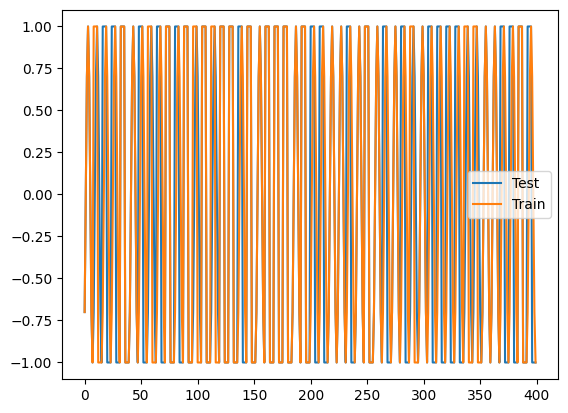

In [17]:
def create_data(nb_periods_train: int, nb_periods_test: int):
    NB_POINTS_PER_PERIOD = 8
    sinus = np.array([-0.7, 0, 0.7, 1, 0.7, 0, -0.7, -1])
    square = np.array([1, 1, 1, 1, -1, -1, -1, -1])

    X_train_base = np.empty((nb_periods_train, NB_POINTS_PER_PERIOD))
    Y_train_base = 2 * np.random.binomial(1, 0.5, nb_periods_train) - 1

    for i in range(nb_periods_train):
        X_train_base[i, :] = sinus if Y_train_base[i] == 1 else square

    X_train = X_train_base.reshape(-1, 1)
    Y_train = np.repeat(Y_train_base, NB_POINTS_PER_PERIOD).reshape(-1, 1)


    X_test_base = np.empty((nb_periods_test, NB_POINTS_PER_PERIOD))
    Y_test_base = 2 * np.random.binomial(1, 0.5, (nb_periods_test, 1)) - 1

    for i in range(nb_periods_test):
        X_test_base[i, :] = sinus if Y_test_base[i] == 1 else square

    X_test = X_test_base.reshape(-1, 1)
    Y_test = np.repeat(Y_test_base, NB_POINTS_PER_PERIOD).reshape(-1, 1)

    return X_test, Y_test, X_train, Y_train

X_test, Y_test, X_train, Y_train = create_data(50, 50)
plt.plot(X_test, label='Test')
plt.plot(X_train, label='Train')
plt.legend()

In [18]:

params_G = [QuantumParameters(
    g_conv=700,
    g_sq=20,
    epsilon_a=50,
    epsilon_b=50,
    delta_a=0,
    delta_b=0
)]

QP_Dudas = JPCConfig(
    DIM_A=12,
    DIM_B=12,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=100
)

QP = QP_Dudas

chip = JpcChip(QP_Dudas)



In [19]:
w = []
QRC_probas = Reservoir(w, chip=chip, mode='probas')
QRC_quadratures = Reservoir(w, chip=chip, mode='quadratures')

In [ ]:
a_probas = QRC_probas.train(X_train, Y_train, params_G, QP, encoding_observable='epsilon')
a_quadratures = QRC_quadratures.train(X_train, Y_train, params_G, QP, encoding_observable='epsilon')

|██████████| 100.0% ◆ elapsed 10m10s ◆ remaining 0.00ms  
|██▎       |  22.6% ◆ elapsed 02m18s ◆ remaining 08m21s  

In [ ]:
Y_probas = QRC_probas.test(X_test, Y_test, params_G, QP_Dudas, encoding_observable='epsilon')
Y_quadratures = QRC_quadratures.test(X_test, Y_test, params_G, QP_Dudas, encoding_observable='epsilon')

|██████████| 100.0% ◆ elapsed 01m05s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 01m06s ◆ remaining 0.00ms  


In [ ]:
treshold = 0
Y_corr_probas = 2 * (Y_probas[0] >= treshold) - 1
print(type(Y_corr_probas))
acc_probas = jnp.sum(Y_corr_probas == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_probas *1e2, '%')\


Y_corr_quadratures = 2 * (Y_quadratures[0] >= treshold) - 1
print(type(Y_corr_quadratures))
acc_quadratures = jnp.sum(Y_corr_quadratures == Y_test) / len(Y_test)
print('Accuracy probas = ', acc_quadratures *1e2, '%')


<class 'jaxlib._jax.ArrayImpl'>
Accuracy probas =  92.5 %
<class 'jaxlib._jax.ArrayImpl'>
Accuracy probas =  77.5 %


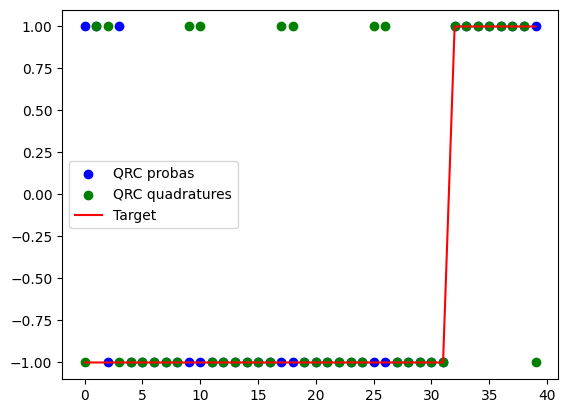

In [ ]:
plt.scatter(range(len(Y_corr_probas)), Y_corr_probas, label='QRC probas', color='b')
plt.scatter(range(len(Y_corr_probas)), Y_corr_quadratures, label='QRC quadratures', color='g')
plt.plot(range(len(Y_test)), Y_test, label='Target', color='r')
plt.legend()
plt.show()

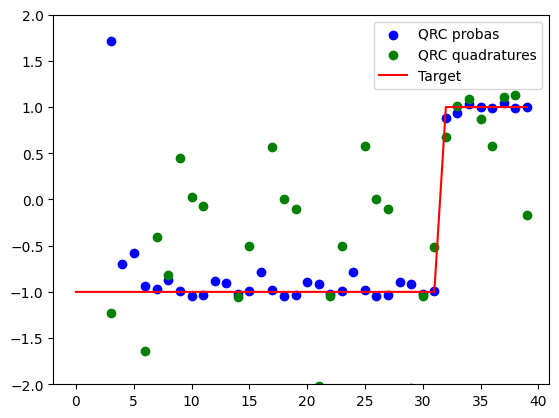

In [ ]:
plt.scatter(range(len(Y_probas[0])), Y_probas[0], label='QRC probas', color='b')
plt.scatter(range(len(Y_quadratures[0])), Y_quadratures[0], label='QRC quadratures', color='g')
plt.plot(range(len(Y_test)), Y_test, label='Target', color='r')
plt.legend()
plt.ylim([-2, 2])
plt.show()